# Data Cleanser

In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import scipy.stats as stats
from scipy.stats.mstats import winsorize

In [2]:
DF = pd.read_csv("patient_health_records.csv")
DF_imput = DF.copy()

In [3]:
print("Rows: ",  DF.shape[0])
print("Columns: ", DF.shape[1])
print("Shape: ", DF.shape)

Rows:  1000
Columns:  9
Shape:  (1000, 9)


In [4]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1000 non-null   int64  
 1   age             900 non-null    float64
 2   gender          900 non-null    object 
 3   region          900 non-null    object 
 4   bmi             902 non-null    float64
 5   blood_pressure  1000 non-null   float64
 6   cholesterol     903 non-null    float64
 7   glucose         902 non-null    float64
 8   disease_risk    1000 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 70.4+ KB


In [5]:
DF.head(10)

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,69.0,Male,South,28.300053,119.967503,185.880159,83.605358,1
1,2,32.0,Male,West,32.176235,139.080885,243.505779,116.866602,1
2,3,89.0,NaN,East,25.813350,102.695640,228.580412,103.437697,0
3,4,78.0,Male,North,20.718467,121.704367,395.890127,118.371016,1
4,5,38.0,Male,West,NaN,217.998200,215.870489,120.507731,0
5,6,NaN,NaN,South,30.087705,140.949427,201.708633,90.801713,0
6,7,20.0,Male,East,26.031238,142.485516,NaN,117.631700,1
7,8,39.0,Female,South,18.974291,120.006319,169.390954,99.717586,0
8,9,70.0,Male,NaN,27.983219,100.627333,162.157430,96.826530,1
9,10,19.0,Male,East,28.847657,126.406460,215.220231,125.047342,1


In [6]:
DF.describe()

,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,1000.000000,900.000000,902.000000,1000.000000,903.000000,902.000000,1000.000000
mean,500.500000,52.482222,25.244964,121.679286,200.485157,105.124710,0.479000
std,288.819436,21.032226,6.048507,18.816221,37.583177,36.292791,0.499809
min,1.000000,18.000000,8.241947,69.907497,51.001796,37.365123,0.000000
25%,250.750000,34.000000,21.508411,110.244895,178.697074,86.938021,0.000000
50%,500.500000,52.000000,25.273991,120.420697,200.193926,100.851186,0.000000
75%,750.250000,71.000000,28.490420,131.181071,221.639327,114.791710,1.000000
max,1000.000000,89.000000,59.174259,217.998200,395.890127,348.618031,1.000000


# Part-A

In [8]:
Missing_Report = (DF.isnull().sum() / len(DF)) *100
print("--- Missing Values Summary (%) ---")
print(Missing_Report[Missing_Report > 0])

--- Missing Values Summary (%) ---
age            10.0
gender         10.0
region         10.0
bmi             9.8
cholesterol     9.7
glucose         9.8
dtype: float64


In [9]:
BMI_Imputer = SimpleImputer(strategy='mean')
DF_imput['bmi'] = BMI_Imputer.fit_transform(DF_imput[['bmi']])

DF_imput.isnull().sum()

patient_id          0
age               100
gender            100
region            100
bmi                 0
blood_pressure      0
cholesterol        97
glucose            98
disease_risk        0
dtype: int64

In [33]:
Region_imputer = SimpleImputer(strategy='most_frequent')
DF_imput['region'] = Region_imputer.fit_transform(DF_imput[['region']]).ravel()

DF_imput.isnull().sum()

patient_id               0
age                      0
gender                   0
region                   0
bmi                      0
blood_pressure           0
cholesterol              0
glucose                  0
disease_risk             0
age_missing_indicator    0
dtype: int64

In [42]:
DF_imput['gender'] = DF_imput['gender'].fillna(DF_imput['gender'].mode()[0])

In [38]:
DF_imput['age_missing_indicator'] = DF_imput['age'].isnull().astype(int)

In [37]:
age_non_missing = DF_imput['age'].dropna()
missing_mask = DF_imput['age'].isnull()

In [36]:
random_samples = np.random.choice(age_non_missing, size=missing_mask.sum())
DF_imput.loc[missing_mask, 'age'] = random_samples

In [15]:
Num_cols = ['cholesterol', 'glucose']

In [16]:
knn_imputer = KNNImputer(n_neighbors=5)
DF_knn_imputed = pd.DataFrame(knn_imputer.fit_transform(DF_imput[Num_cols]), columns=Num_cols)
DF_imput['cholesterol_knn'] = DF_knn_imputed['cholesterol']

In [17]:
mice_imputer = IterativeImputer(random_state=42)
DF_mice_imputed = pd.DataFrame(mice_imputer.fit_transform(DF_imput[Num_cols]), columns=Num_cols)
DF_imput['glucose_mice'] = DF_mice_imputed['glucose']

In [18]:
DF_imput['cholesterol'] = DF_imput['cholesterol_knn']
DF_imput['glucose'] = DF_imput['glucose_mice']
DF_imput.drop(['cholesterol_knn', 'glucose_mice'], axis=1, inplace=True)

In [43]:
DF_imput.isnull().sum()

patient_id               0
age                      0
gender                   0
region                   0
bmi                      0
blood_pressure           0
cholesterol              0
glucose                  0
disease_risk             0
age_missing_indicator    0
dtype: int64

# Part-B

In [20]:
DF_outliers = DF_imput.copy()

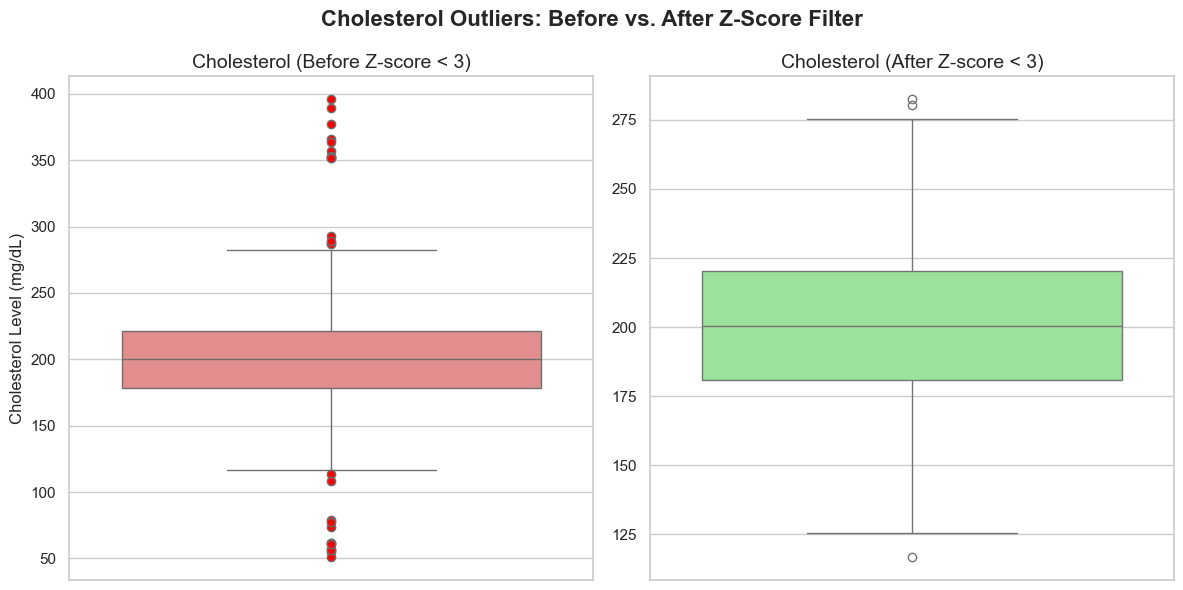

In [63]:
z_scores = np.abs(stats.zscore(DF_outliers['cholesterol']))
DF_outliers = DF_outliers[z_scores < 3]

cholesterol_before = DF['cholesterol'].copy()
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.suptitle('Cholesterol Outliers: Before vs. After Z-Score Filter', fontsize=16, weight='bold')

sns.boxplot(
    y=cholesterol_before, 
    ax=axes[0], 
    color='lightcoral',
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6} # Highlights outliers in red
)
axes[0].set_title('Cholesterol (Before Z-score < 3)', fontsize=14)
axes[0].set_ylabel('Cholesterol Level (mg/dL)', fontsize=12)
sns.boxplot(
    y=DF_outliers['cholesterol'], 
    ax=axes[1], 
    color='lightgreen'
)
axes[1].set_title('Cholesterol (After Z-score < 3)', fontsize=14)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [23]:
Q1 = DF_outliers['bmi'].quantile(0.25)
Q3 = DF_outliers['bmi'].quantile(0.75)

In [24]:
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

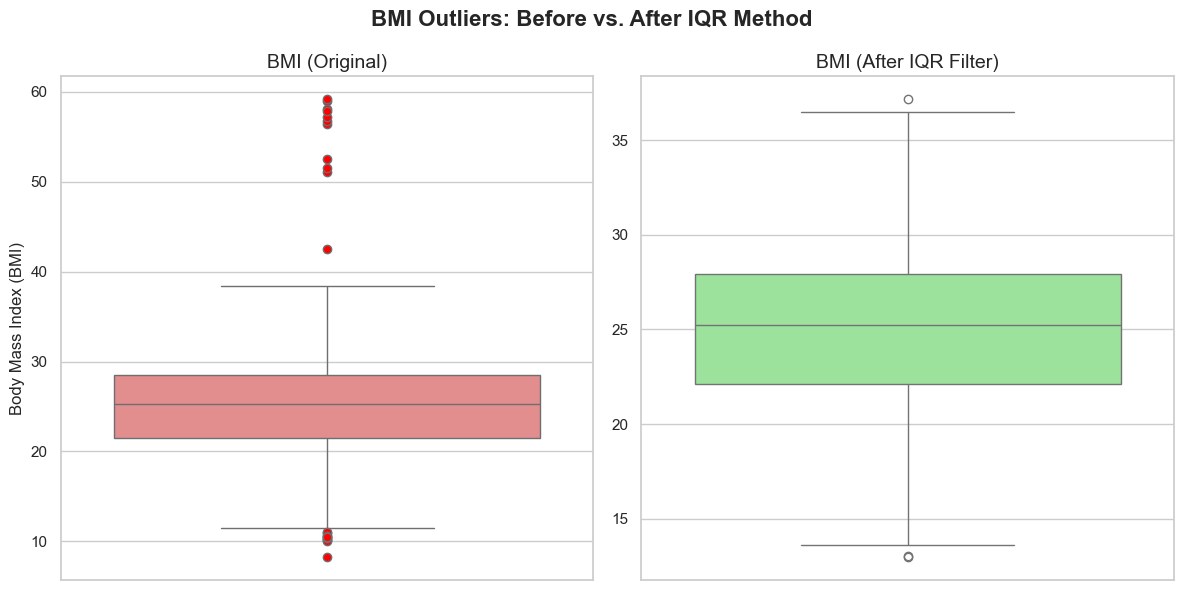

In [62]:
DF_outliers = DF_outliers[(DF_outliers['bmi'] >= lower_bound) & (DF_outliers['bmi'] <= upper_bound)]

bmi_before = DF['bmi'].copy()
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.suptitle('BMI Outliers: Before vs. After IQR Method', fontsize=16, weight='bold')

sns.boxplot(
    y=bmi_before, 
    ax=axes[0], 
    color='lightcoral',
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6} # Highlights outliers in red
)
axes[0].set_title('BMI (Original)', fontsize=14)
axes[0].set_ylabel('Body Mass Index (BMI)', fontsize=12)

sns.boxplot(
    y=DF_outliers['bmi'], 
    ax=axes[1], 
    color='lightgreen'
)
axes[1].set_title('BMI (After IQR Filter)', fontsize=14)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

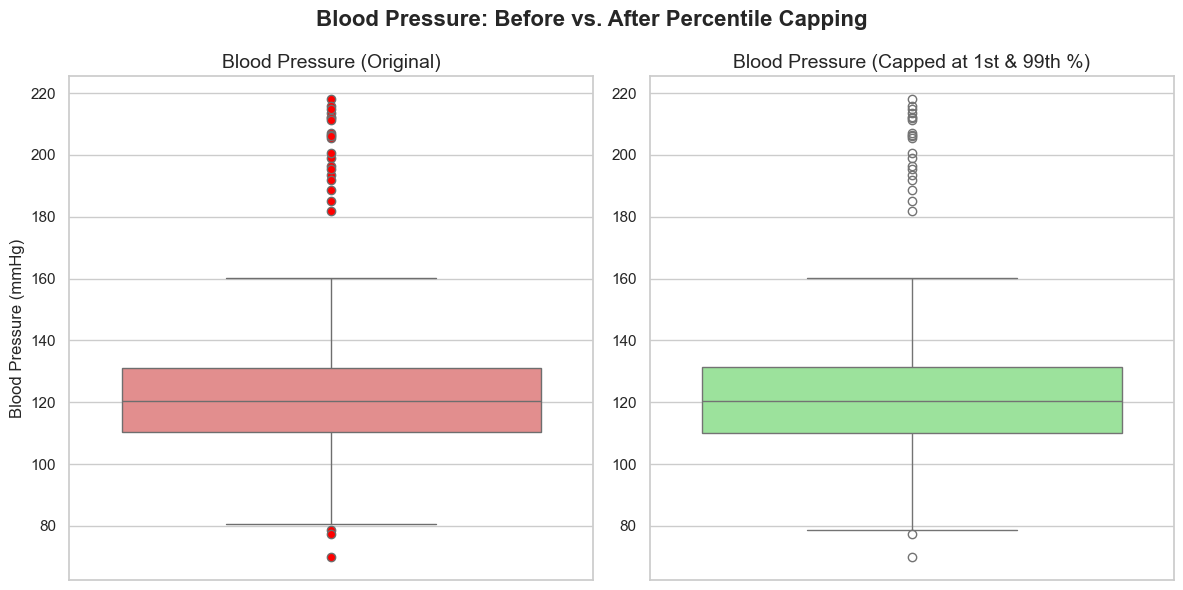

In [60]:
p1 = DF_outliers['blood_pressure'].quantile(0.01)
p99 = DF_outliers['blood_pressure'].quantile(0.99)

blood_pressure_before = DF['blood_pressure'].copy()
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
fig.suptitle('Blood Pressure: Before vs. After Percentile Capping', fontsize=16, weight='bold')

# Plot BEFORE capping
sns.boxplot(
    y=blood_pressure_before, 
    ax=axes[0], 
    color='lightcoral',
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6} # Highlights outliers
)
axes[0].set_title('Blood Pressure (Original)', fontsize=14)
axes[0].set_ylabel('Blood Pressure (mmHg)', fontsize=12)

# Plot AFTER capping
sns.boxplot(
    y=DF_outliers['blood_pressure'], 
    ax=axes[1], 
    color='lightgreen'
)
axes[1].set_title('Blood Pressure (Capped at 1st & 99th %)', fontsize=14)
axes[1].set_ylabel('')

# Show the plot
plt.tight_layout()
plt.show()

Winsorization applied successfully to all columns.
Dataset shape remains unchanged: (1000, 10)


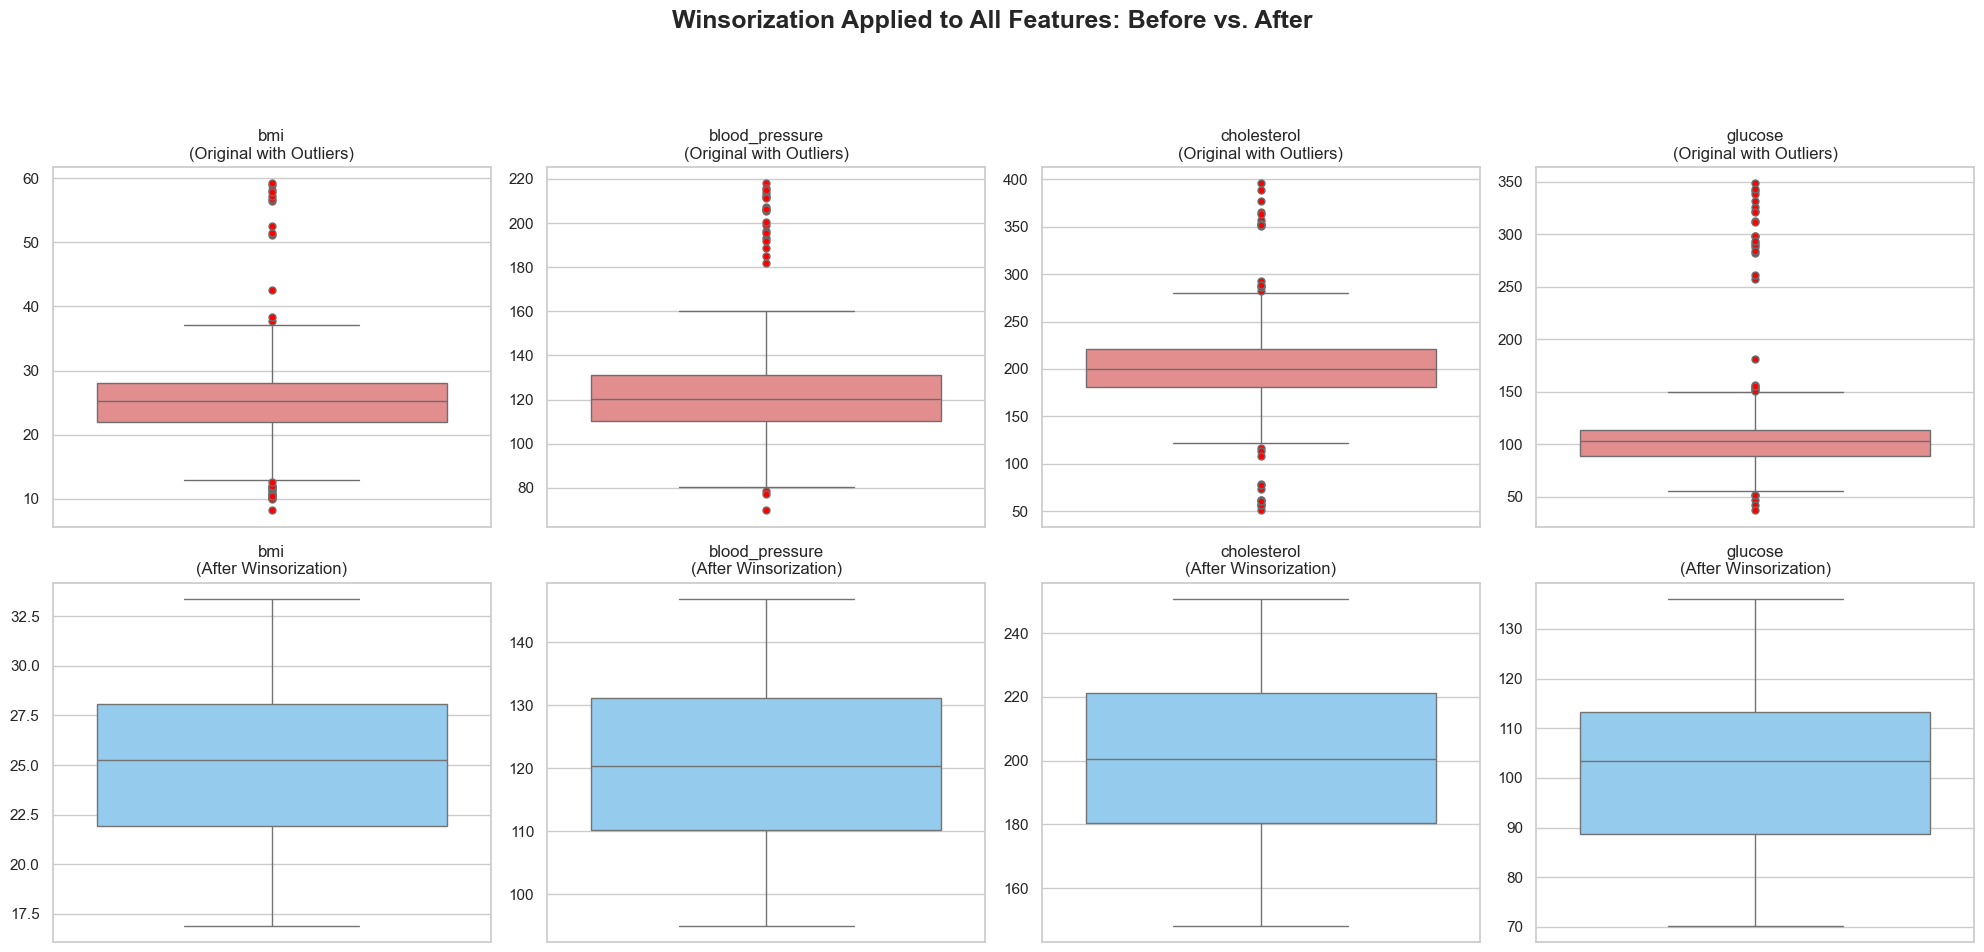

In [53]:
DF_winsorized = DF_imput.copy()
cols_to_winsorize = ['bmi', 'blood_pressure', 'cholesterol', 'glucose']

for col in cols_to_winsorize:
    DF_winsorized[col] = winsorize(DF_winsorized[col], limits=[0.05, 0.05])

print("Winsorization applied successfully to all columns.")
print(f"Dataset shape remains unchanged: {DF_winsorized.shape}")

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle('Winsorization Applied to All Features: Before vs. After', fontsize=18, weight='bold')

for i, col in enumerate(cols_to_winsorize):
    sns.boxplot(
        y=DF_imput[col], 
        ax=axes[0, i], 
        color='lightcoral',
        flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5} # Highlight outliers
    )
    axes[0, i].set_title(f'{col}\n(Original with Outliers)', fontsize=12)
    axes[0, i].set_ylabel('')

    sns.boxplot(
        y=DF_winsorized[col], 
        ax=axes[1, i], 
        color='lightskyblue'
    )
    axes[1, i].set_title(f'{col}\n(After Winsorization)', fontsize=12)
    axes[1, i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

# Part-C

In [49]:
DF_Final = DF_outliers.copy()

In [50]:
DF_Final

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing_indicator
0,1,69.0,Male,South,28.300053,119.967503,185.880159,83.605358,1,0
1,2,32.0,Male,West,32.176235,139.080885,243.505779,116.866602,1,0
2,3,89.0,Female,East,25.813350,102.695640,228.580412,103.437697,0,0
4,5,38.0,Male,West,25.244964,217.998200,215.870489,120.507731,0,0
5,6,49.0,Female,South,30.087705,140.949427,201.708633,90.801713,0,1
...,...,...,...,...,...,...,...,...,...,...
995,996,27.0,Female,North,30.371338,112.479519,204.004461,136.096687,0,0
996,997,51.0,Female,South,22.898024,105.567162,189.760156,87.650257,0,0
997,998,50.0,Female,East,31.813085,127.536709,199.653461,98.511724,0,1
998,999,49.0,Male,North,26.650713,117.615964,179.801326,69.627935,0,0


In [64]:
print(DF_Final.info())
DF_Final.to_csv('output.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             952 non-null    int64  
 1   age                    952 non-null    float64
 2   gender                 952 non-null    object 
 3   region                 952 non-null    object 
 4   bmi                    952 non-null    float64
 5   blood_pressure         952 non-null    float64
 6   cholesterol            952 non-null    float64
 7   glucose                952 non-null    float64
 8   disease_risk           952 non-null    int64  
 9   age_missing_indicator  952 non-null    int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 81.8+ KB
None


* Effective Imputation Strategy: MICE (Iterative Imputer) and KNN proved highly effective for medical attributes like cholesterol and glucose because these physiological variables are often correlated with one another. Simple mean/mode imputation was sufficient and efficient for independent variables like region and gender.

* Best Outlier Handling Method: Winsorization and Percentile capping proved best for features like blood_pressure and glucose because they preserved the dataset size (no data loss) while reining in extreme spikes that would otherwise skew a machine learning model's weights. The IQR and Z-score methods were effective but resulted in dropped rows, reducing the total volume of training data.

* Usability Improvement: By removing NaN values and capping extreme biological impossibilities (like a BMI of 60 or glucose of 350+ not corresponding to severe active crisis), the dataset is now in a standardized format. Algorithms like Logistic Regression or Random Forests will no longer throw errors regarding missing data, and gradient descent-based algorithms will converge much faster without extreme outliers skewing the loss function.